   Unnamed: 0 school sex  age address famsize Pstatus  Medu  Fedu     Mjob  \
0           0     GP   F   18       U     GT3       A     4     4  at_home   
1           1     GP   F   17       U     GT3       T     1     1  at_home   
2           2     GP   F   15       U     LE3       T     1     1  at_home   
3           3     GP   F   15       U     GT3       T     4     2   health   
4           4     GP   F   16       U     GT3       T     3     3    other   

   ... famrel_y freetime_y goout_y  Dalc_y  Walc_y  health_y absences_y G1_y  \
0  ...        4          3       4       1       1         3          4    0   
1  ...        5          3       3       1       1         3          2    9   
2  ...        4          3       2       2       3         3          6   12   
3  ...        3          2       2       1       1         5          0   14   
4  ...        4          3       2       1       2         5          0   11   

  G2_y G3_y  
0   11   11  
1   11   11  
2   13  

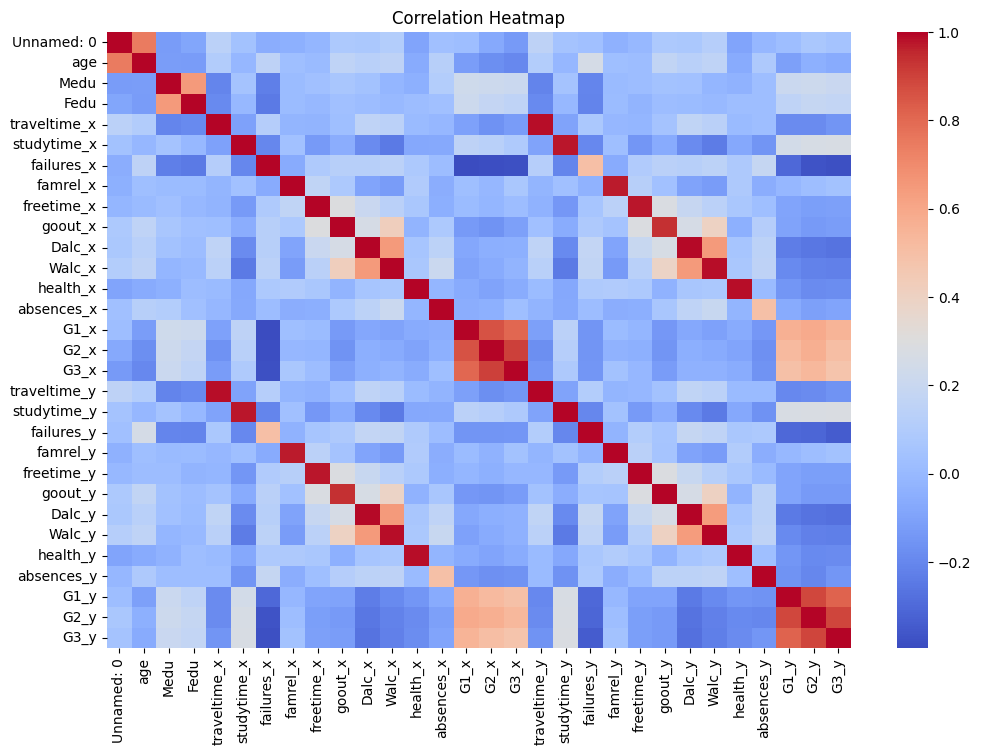

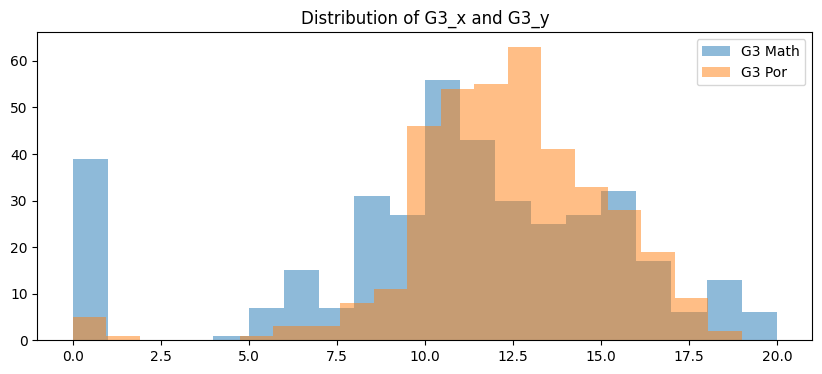

In [8]:
# =============================
# Cell 1: EDA
# =============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load file merge
df = pd.read_csv(r"D:\học python\KHDL\w7\student-merge.csv")

# Quick look
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

# Chuyển cột điểm sang numeric
df['G3_x'] = pd.to_numeric(df['G3_x'], errors='coerce')
df['G3_y'] = pd.to_numeric(df['G3_y'], errors='coerce')

# Heatmap tương quan các cột số
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()

# Histogram G3_x và G3_y
plt.figure(figsize=(10,4))
plt.hist(df['G3_x'], bins=20, alpha=0.5, label='G3 Math')
plt.hist(df['G3_y'], bins=20, alpha=0.5, label='G3 Por')
plt.legend()
plt.title("Distribution of G3_x and G3_y")
plt.show()
df['pass_all'] = ((df['G3_x'] >= 10) & (df['G3_y'] >= 10)).astype(int)

R2 score: 0.8500134077056337


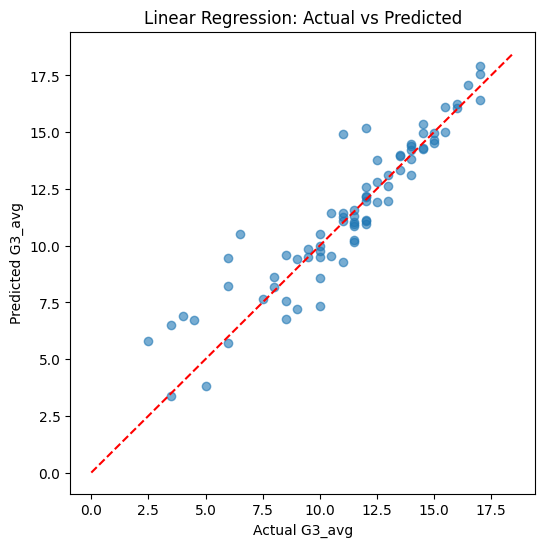

In [3]:
# =============================
# Cell 2: Regression
# =============================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Target: dự đoán G3_avg (trung bình 2 môn)
df['G3_avg'] = (df['G3_x'] + df['G3_y']) / 2

# Chọn feature numeric (loại bỏ target)
df_model = df.select_dtypes(include=np.number)
X = df_model.drop(['G3_x','G3_y','G3_avg','Unnamed: 0'], axis=1)
y = df_model['G3_avg']

# Chia train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("R2 score:", r2_score(y_test, y_pred))

# Plot y_test vs y_pred
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual G3_avg")
plt.ylabel("Predicted G3_avg")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

In [4]:
# =============================
# Cell 3: Pass/Fail
# =============================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Tạo nhãn pass_all: cả 2 môn >=10
df_model['pass_all'] = ((df['G3_x'] >= 10) & (df['G3_y'] >= 10)).astype(int)

# Feature numeric
X_log = df_model.drop(['G3_x','G3_y','G3_avg','pass_all','Unnamed: 0'], axis=1)
y_log = df_model['pass_all']

# Train/test
X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8701298701298701
Confusion Matrix:
 [[21  6]
 [ 4 46]]


In [5]:
# =============================
# Cell 4: KMeans
# =============================
from sklearn.cluster import KMeans

X_cluster = df_model.drop(['G3_x','G3_y','G3_avg','pass_all','Unnamed: 0'], axis=1)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_cluster)
df_model['cluster'] = clusters

print("Cluster counts:\n", df_model['cluster'].value_counts())

Cluster counts:
 cluster
1    285
0     94
2      3
Name: count, dtype: int64


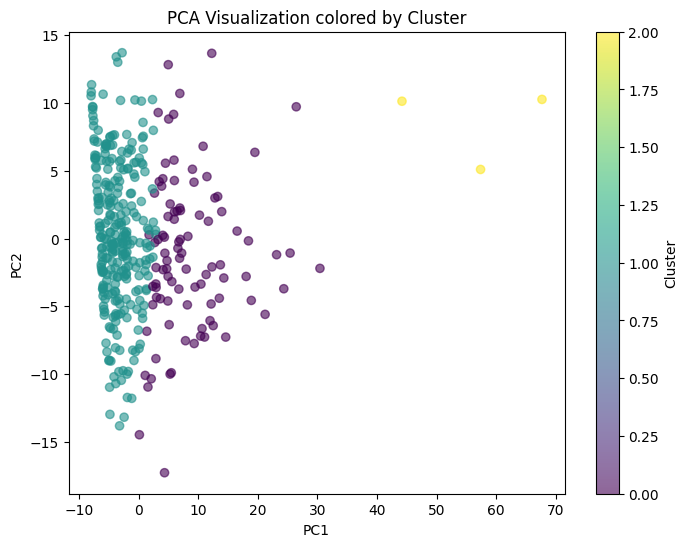

In [6]:
# =============================
# Cell 5: PCA
# =============================
from sklearn.decomposition import PCA

X_pca = df_model.drop(['G3_x','G3_y','G3_avg','pass_all','Unnamed: 0','cluster'], axis=1)
pca = PCA(n_components=2)
X_pca_2d = pca.fit_transform(X_pca)

plt.figure(figsize=(8,6))
plt.scatter(X_pca_2d[:,0], X_pca_2d[:,1], c=df_model['cluster'], cmap='viridis', alpha=0.6)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Visualization colored by Cluster")
plt.colorbar(label='Cluster')
plt.show()

In [9]:
# =============================
# Cell 7: Explain & Bias
# =============================
# Kiểm tra điểm trung bình G3 theo giới tính
if "sex" in df.columns:
    print("Average G3_x and G3_y by sex:")
    print(df.groupby("sex")[['G3_x','G3_y']].mean())

# Kiểm tra phân bố pass_all theo giới tính
if "sex" in df.columns:
    print("\nPass/Fail counts by sex:")
    print(df.groupby("sex")['pass_all'].value_counts())

# Nhận xét bias nếu có:
# - Nếu 1 nhóm (sex, school) có pass thấp hơn, đây là bias tiềm ẩn
# - Dùng kết quả feature importance để giải thích ảnh hưởng biến

Average G3_x and G3_y by sex:
          G3_x       G3_y
sex                      
F     9.838384  13.085859
M    10.978261  11.902174

Pass/Fail counts by sex:
sex  pass_all
F    1           121
     0            77
M    1           125
     0            59
Name: count, dtype: int64
